---
title: "Comparison of low rank matrix with LDSC slopes / intercepts"
author: "Saikat Banerjee"
format:
  html: default
date: "2026-06-11"
file-modified: "2026-06-11"
abstract: "LDSC slopes give genetic correlation (signal) and intercepts give noise covariance. In this notebook, we quantify how the low rank matrix tracks signal and noise."

---

In [1]:
import json
from pathlib import Path
import pickle

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from pymir import mpl_stylesheet
from pymir import mpl_utils
mpl_stylesheet.banskt_presentation(splinecolor='black', dpi=300, colors='kelly')

from matplotlib import colormaps as mpl_cmaps
import matplotlib.colors as mpl_colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

from scipy.stats import spearmanr, rankdata, pearsonr
from clorinn import MatrixFactorization

## Functions for loading results / matrices

In [2]:
def normalize_trait_name(name):
    rename_map = {
        "Saxena": "Daytime_sleepiness",
    }
    if not isinstance(name, str):
        return name
    name = name.replace("-", "_")
    name = rename_map.get(name, name)
    return str(name)
    

def get_matrix_df_from_json(fpath, check_sanity=True):
    with open(Path(fpath), "r") as f:
        d = json.load(f)
    rows = []
    traits = []
    for a_vs_b, val in d.items():
        trait_a, trait_b = ([normalize_trait_name(x) for x in a_vs_b.split("_vs_")])
        traits.append(trait_a)
        traits.append(trait_b)
        rows.append({
            "trait_a": trait_a,
            "trait_b": trait_b,
            "rg": val,
        })
    traits = sorted(list(set(traits)))
    df = pd.DataFrame(rows)

    n = len(traits)
    R = pd.DataFrame(np.nan, index=traits, columns=traits, dtype=float)
    R.values[R.index.get_indexer(df["trait_a"]),
             R.columns.get_indexer(df["trait_b"])] = df["rg"].to_numpy()
    R.values[R.index.get_indexer(df["trait_b"]),
             R.columns.get_indexer(df["trait_a"])] = df["rg"].to_numpy()

    if check_sanity:
        # Max and min values
        print(f"max={R.max().max():.3g}, min={R.min().min():.3g}")
        # Symmetry sanity (in case the input accidentally contains BOTH directions)
        asym = np.nanmax(np.abs(R.values - R.values.T))
        print(f"max |R - R.T| = {asym:.3g}")   # expect 0.0 if each pair listed once
        
        # Coverage: how many off-diagonal pairs are actually populated?
        off = ~np.eye(len(traits), dtype=bool)
        print(f"populated off-diagonal fraction: {np.isfinite(R.values[off]).mean():.3f}")
        
    return R

def load_zscore(zscore_path):
    df = pd.read_csv(Path(zscore_path), header=0, index_col=0, dtype={0: str})
    df.index = df.index.map(str)
    df.columns = df.columns.map(str)
    return df

def load_categories(path):
    with open(path, 'r') as f:
        data = json.load(f)
    return data

def impute_by_category(df, traits_meta):
    categories = {t:meta['group'] for t,meta in traits_meta.items()}
    cats = df.index.map(categories)
    group_means = df.groupby(cats).transform('mean')
    df_imputed = df.fillna(group_means)
    
    # the rest has to be filled by column means
    arr = df_imputed.to_numpy()
    col_means = np.nanmean(df.to_numpy(), axis=0)
    rows, cols = np.where(np.isnan(arr))
    arr[rows, cols] = np.take(col_means, cols)
    return arr

def load_fit_result(fit_result_dir, prefix, r):
    path = Path(fit_result_dir) / f"{prefix}_r{r}.pkl"
    with open(path, 'rb') as f:
        fit_artifact = pickle.load(f)
    return fit_artifact["final_result"]

## Functions for comparing X with noise/signal from LDSC

In [3]:
def cov2corr(M, eps=1e-12):
    M = np.asarray(M, float)
    M = 0.5 * (M + M.T)

    d = np.sqrt(np.clip(np.diag(M), eps, None))
    R = M / np.outer(d, d)
    np.fill_diagonal(R, 1.0)
    return R

def linfit_residual(a, b):
    # residual of a after linear fit on covariate b
    B = np.c_[np.ones_like(b), b]
    beta = np.linalg.lstsq(B, a, rcond=None)[0]
    return a - B @ beta


def recovery_metrics(
    X, ids, Rg_df, intercept_df, 
    Rg_se_df=None, rg_clip=1.0, se_max=0.5, 
    n_perm=10000, seed=0, center_X=True):
    
    def aligned(M):
        return M.reindex(index=ids, columns=ids).to_numpy(float)
    
    X = np.asarray(X, float)
    
    if center_X:
        X = X - X.mean(axis=1, keepdims=True)

    # recovered trait-trait correlation structure in data space
    C = cov2corr(X @ X.T)
    
    # LDSC genetic correlation
    Rg = aligned(Rg_df)
    Rg = 0.5 * (Rg + Rg.T)
    Rg = np.clip(Rg, -rg_clip, rg_clip)
    Rg_se = aligned(Rg_se_df) if Rg_se_df is not None else None
    
    # LDSC intercept / noise covariance, converted to correlation scale
    S = cov2corr(aligned(intercept_df))
    
    iu = np.triu_indices(len(ids), k=1)
    c, rg, noise = C[iu], Rg[iu], S[iu]
    ok = np.isfinite(c) & np.isfinite(rg) & np.isfinite(noise)
    if Rg_se is not None: 
        ok &= np.isfinite(Rg_se[iu]) & (Rg_se[iu] < se_max)

    c_rank     = rankdata(c[ok])
    noise_rank = rankdata(noise[ok]) # control = noise rank, fixed across perms
    rg_rank    = rankdata(rg[ok])
    
    # partial Spearman(C, Rg | noise)
    res_c_noise  = linfit_residual(c_rank, noise_rank)
    res_rg_noise = linfit_residual(rg_rank, noise_rank)
    partial_rg   = pearsonr(res_c_noise, res_rg_noise)[0]

    # partial Spearman(C, noise | Rg)
    res_c_rg     = linfit_residual(c_rank, rg_rank)
    res_noise_rg = linfit_residual(noise_rank, rg_rank)
    partial_noise = pearsonr(res_c_rg, res_noise_rg)[0]
    
    vs_rg    = spearmanr(c[ok], rg[ok]).statistic
    vs_noise = spearmanr(c[ok], noise[ok]).statistic

    # rng = np.random.default_rng(seed)
    # n = len(ids)
    # null = np.empty(n_perm)
    # for b in range(n_perm):  # partial Mantel: permute model trait labels
    #     perm = rng.permutation(n)
    #     Cp = C[np.ix_(perm, perm)]
    #     cc = Cp[iu][ok]
    #     cc_rank = rankdata(cc)
    #     res_cc = linfit_residual(cc_rank, noise_rank)
    #     null[b] = pearsonr(res_cc, res_rg_noise)[0]
    # p = (np.sum(np.abs(null) >= abs(partial)) + 1)/(n_perm+1)

    clean = ok & (np.abs(noise) < 0.05)
    vs_clean = spearmanr(c[clean], rg[clean]).statistic
    return dict(
        partial_rg_given_noise=partial_rg,
        partial_noise_given_rg=partial_noise,
        # partial_rg_given_noise=p,
        spearman_vs_rg=vs_rg, 
        spearman_vs_noise=vs_noise,
        spearman_vs_rg_clean=vs_clean, 
        n=int(ok.sum()), 
        n_clean=int(clean.sum()))

## Build recovery dataframes

- $\mathbf{S} = \mathbb{I}$
- $\mathbf{S} =$ LDSC intercepts
- $\mathbf{S} =$ Shielded sampling covariance
- $\mathbf{S} =$ GLEANR sampling covariance

In [4]:
analysis_root = "/gpfs/commons/groups/knowles_lab/data/PsychGen/analysis"
data_root = "/gpfs/commons/groups/knowles_lab/data/PsychGen/input"
version_  = "v1.1" # 78 traits

R    = get_matrix_df_from_json(Path(data_root) / "ldsc_results/rg.txt")
np.fill_diagonal(R.values, 1.0)

R_se = get_matrix_df_from_json(Path(data_root) / "ldsc_results/rg_se.txt")
R_p  = get_matrix_df_from_json(Path(data_root) / "ldsc_results/rg_p.txt")

G    = get_matrix_df_from_json(Path(data_root) / "ldsc_results/gencov.txt")
G_se = get_matrix_df_from_json(Path(data_root) / "ldsc_results/gencov_se.txt")

noise_path  = Path(data_root) / "pgc_v1.1/sampling_covariance_v1_1.csv"
zscore_path = Path(data_root) / "pgc_v1.1/zscore_v1_1.csv"
S = load_zscore(noise_path)
Z = load_zscore(zscore_path)
traits_meta = load_categories(Path(data_root) / "trait_metadata.json")
trait_names = list(Z.index)

model_variants = {
    'identity': {
        'result_dir': Path(analysis_root) / "v1.1/low_rank_fit/fit_result",
        'prefix': "pgd_fw_nnm",
    },
    'intercepts': {
        'result_dir': Path(analysis_root) / "v1.1/low_rank_fit/fit_result",
        'prefix': "pgd_fw_nnm_corr",
    },
    'shielded': {
        'result_dir': Path(analysis_root) / "v1.3/low_rank_fit/fit_result",
        'prefix': "pgd_fw_nnm_corr",
    },
    'shrinked': {
        'result_dir': Path(analysis_root) / "v1.5/low_rank_fit/fit_result",
        'prefix': "pgd_fw_nnm_corr",
    },
}

rank_list = [64, 128, 256, 323, 406, 512, 
          645, 813, 1024, 1290, 1625, 2048,
          2580, 3251, 4096, 5161, 6502, 8192, 16384]

def get_data_for_nucnorm(fit_result_dir, prefix, r_choose):
    fit_res = load_fit_result(fit_result_dir, prefix, r_choose)
    return fit_res.X

def build_dataframe_from_X_dict(X_dict, trait_ids, R, S, R_se):
    rows = {}
    for nucnorm, X in X_dict.items():
        res = recovery_metrics(X, trait_ids, R, S, R_se)
        rows[nucnorm] = res
    return pd.DataFrame(rows).T

data = {vname: dict() for vname in model_variants.keys()}
for nucnorm in rank_list:
    for vname, vparams in model_variants.items():
        data[vname][nucnorm] = get_data_for_nucnorm(
            vparams['result_dir'], vparams['prefix'], nucnorm)
        
recovery_df = {}
for vname, vparams in model_variants.items():
    recovery_df[vname] = build_dataframe_from_X_dict(
        data[vname], trait_names, R, S, R_se)
    
recovery_df_raw = recovery_metrics(Z, trait_names, R, S, R_se)

max=3.87, min=-0.893
max |R - R.T| = 0
populated off-diagonal fraction: 0.949
max=10.8, min=0.00195
max |R - R.T| = 0
populated off-diagonal fraction: 0.949
max=0.999, min=0
max |R - R.T| = 0
populated off-diagonal fraction: 0.949
max=0.235, min=-0.104
max |R - R.T| = 0
populated off-diagonal fraction: 0.951
max=0.0508, min=0.0005
max |R - R.T| = 0
populated off-diagonal fraction: 0.951


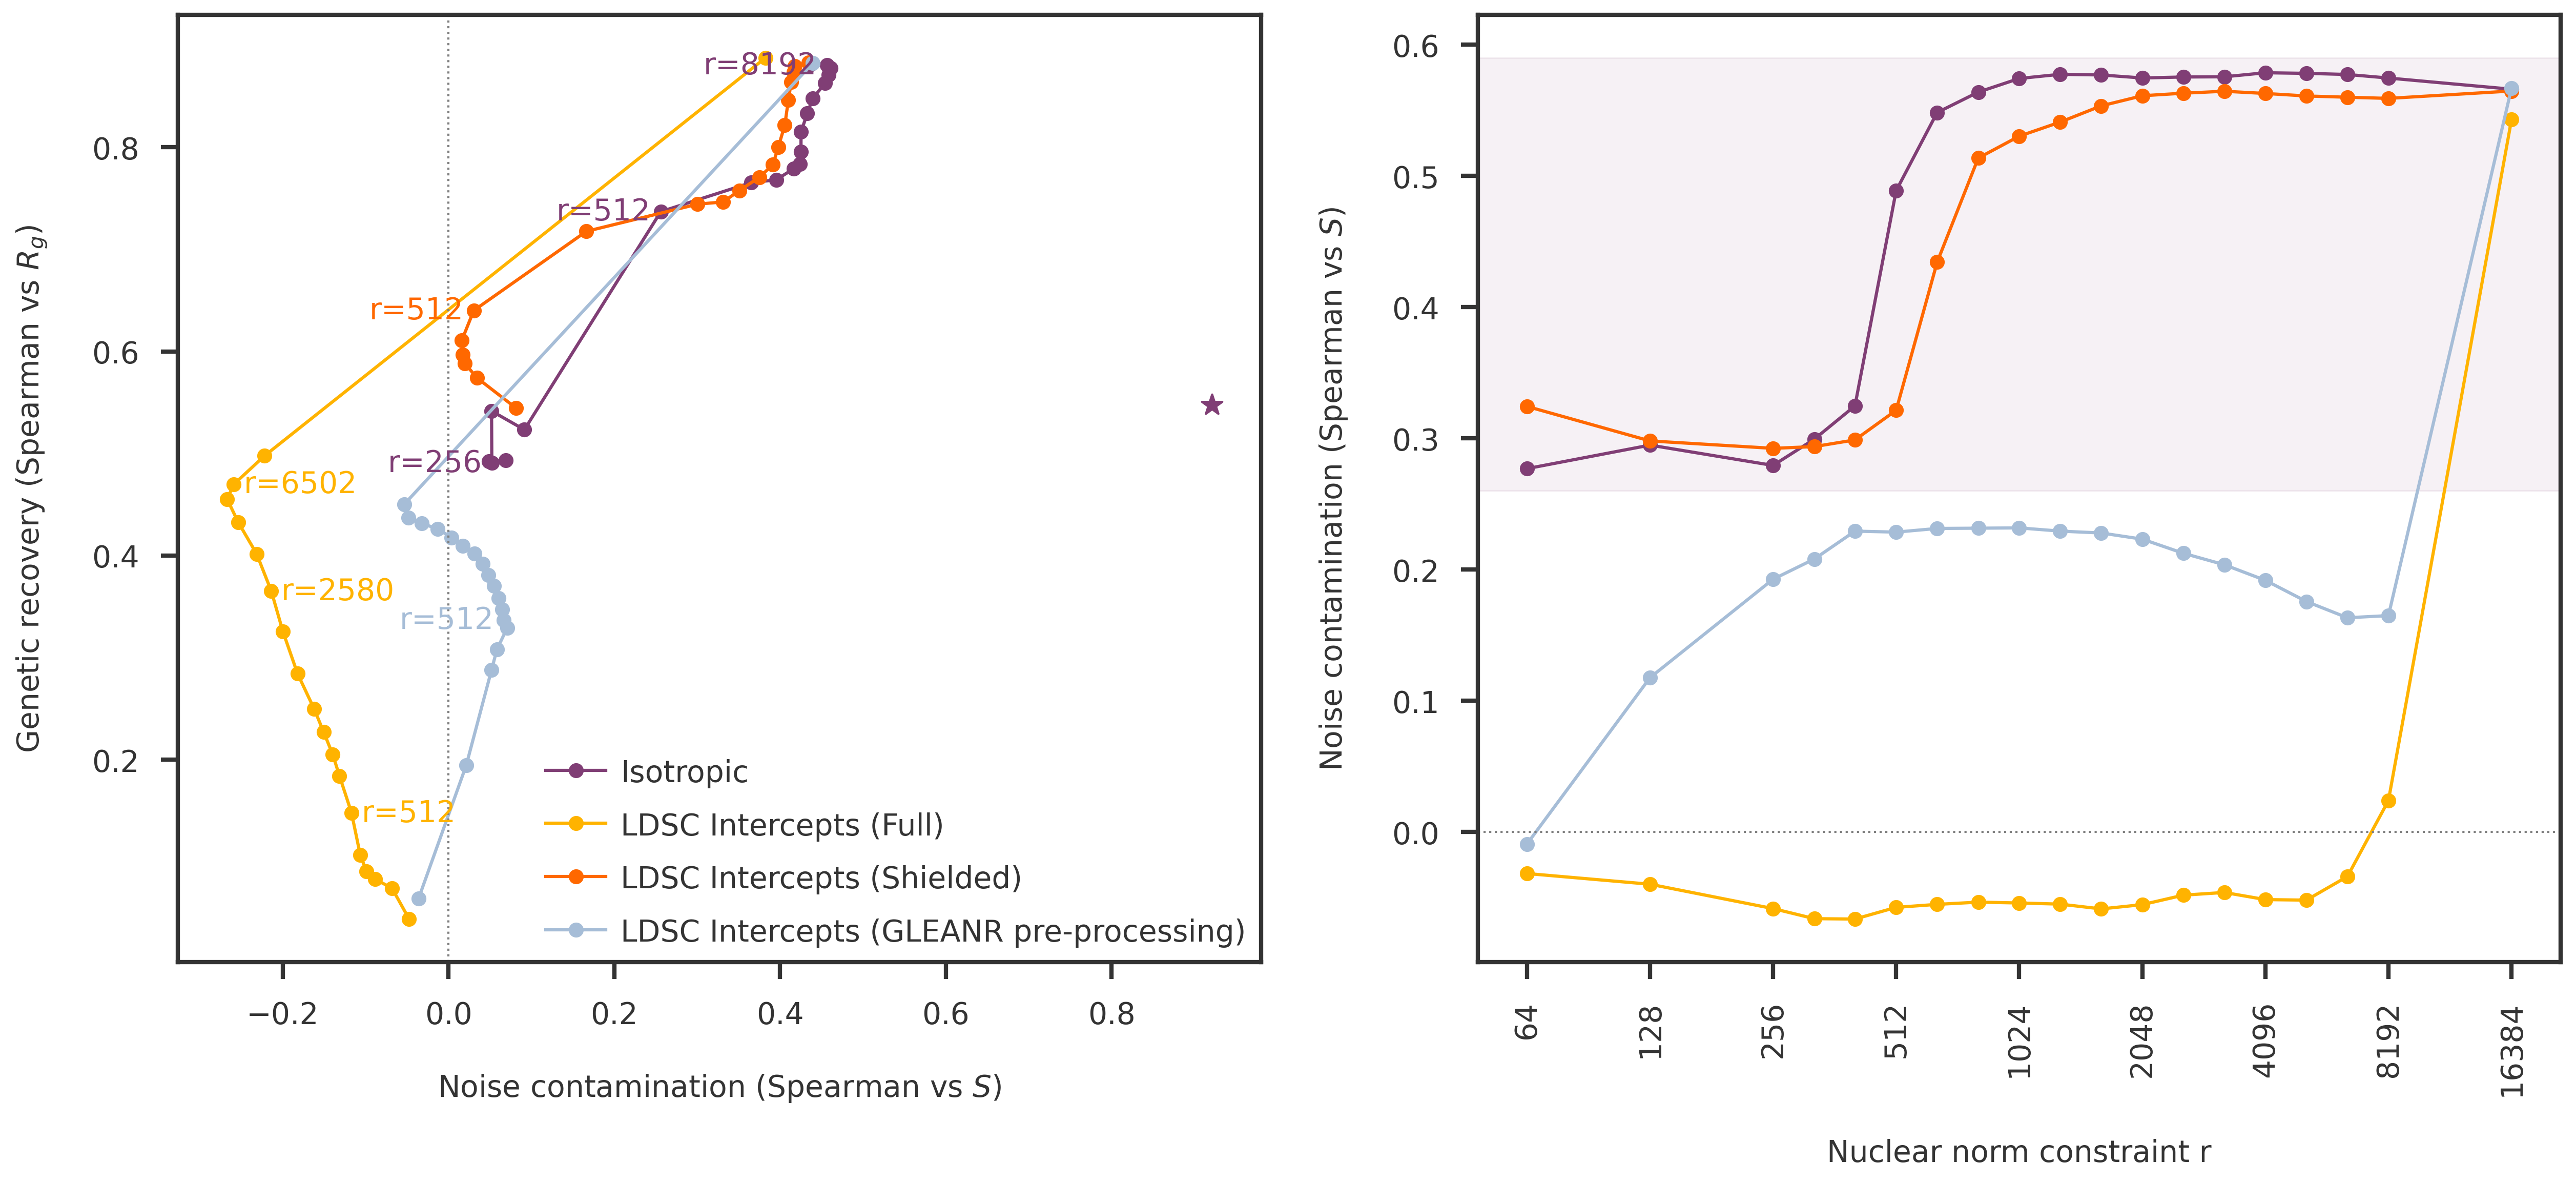

In [6]:
def get_r_scaled(x, scale="log2"):
    x = np.asarray(x, dtype=float)
    powers = np.arange(np.ceil(np.log2(x.min())), np.floor(np.log2(x.max())) + 1)
    xlabels = 2 ** powers
    
    if scale == "log10":
        xscale = np.log10(x)
        xticks = np.log10(xlabels)
    elif scale == "log2":
        xscale = np.log2(x)
        xticks = np.log2(xlabels)
    else:
        xscale = x
        xticks = xlabels

    xlabel_str = [f"{r:g}" for r in xlabels]
    return xscale, xticks, xlabel_str

plot_variants = {
    'identity': {
        'label': "Isotropic",
        'tag_locs': [256, 512, 8192],
        'tag_dx': -0.012,
        'tag_dy': 0.0,
        'tag_ha': "right",
    },
    'intercepts': {
        'label': "LDSC Intercepts (Full)",
        'tag_locs': [512, 2580, 6502],
        'tag_dx': 0.012,
        'tag_dy': 0.0,
        'tag_ha': "left",
    },
    'shielded': {
        'label': "LDSC Intercepts (Shielded)",
        'tag_locs': [512],
        'tag_dx': -0.012,
        'tag_dy': 0.0,
        'tag_ha': "right",
    },
    'shrinked': {
        'label': "LDSC Intercepts (GLEANR pre-processing)",
        'tag_locs': [512],
        'tag_dx': -0.012,
        'tag_dy': 0.0,
        'tag_ha': "right",
    },
}

fig = plt.figure(figsize = (20,8))
gs  = fig.add_gridspec(nrows=1, ncols=2, wspace=0.2, hspace=0)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

xcolname = "partial_noise_given_rg"
ycolname = "partial_rg_given_noise"
# xcolname = "spearman_vs_noise"
# ycolname = "spearman_vs_rg"
lines = {}
for vname, vparams in plot_variants.items():
    df = recovery_df[vname]
    lines[vname], = ax1.plot(df[xcolname], df[ycolname], 'o-', label=vparams['label'])

def make_tag_on_lines(df, rlist, dx, dy, color, ha='left'):
    for r in rlist:
        x, y = df.loc[r, xcolname], df.loc[r, ycolname]
        ax1.annotate(f'r={r}', (x,y), (x+dx,y+dy), color=color, ha=ha, va='center')
ax1.axvline(0, color='gray', lw=1, ls='dotted')
        
for vname, vparams in plot_variants.items():
    make_tag_on_lines(
        recovery_df[vname], vparams['tag_locs'], 
        vparams['tag_dx'], vparams['tag_dy'], 
        lines[vname].get_color(),
        ha=vparams['tag_ha'],
    )
    
ax1.scatter(recovery_df_raw[xcolname], recovery_df_raw[ycolname], marker="*", s=100)
    
ax1.legend(handlelength=2)
ax1.set_xlabel(r"Noise contamination (Spearman vs $S$)")
ax1.set_ylabel(r"Genetic recovery (Spearman vs $R_g$)")
# ax1.set_ylabel(r"Genetic recovery (Spearman vs $R_g$ where $|G| < 0.05$ )")

ycolname = "spearman_vs_noise"
x, xticks, xlabels  = get_r_scaled(rank_list, scale="log2")
for vname, vparams in plot_variants.items():
    df = recovery_df[vname]
    ax2.plot(x, df[ycolname], 'o-', label=vparams['label'], color=lines[vname].get_color())
    
ax2.axhline(0, color='gray', lw=1, ls='dotted')
ax2.axhspan(0.26, 0.59, color=lines['identity'].get_color(), alpha=0.07)

ax2.set_xticks(xticks)
ax2.set_xticklabels(xlabels, rotation=90)
ax2.set_xlabel("Nuclear norm constraint r")
ax2.set_ylabel(r"Noise contamination (Spearman vs $S$)")


# outfile_name=f"figures/pgc_recovery_contamination_tradeoff_78_traits"
# plt.savefig(f"{outfile_name}.pdf", bbox_inches='tight')
# plt.savefig(f"{outfile_name}.png", bbox_inches='tight')
plt.show()